<a href="https://colab.research.google.com/github/Jonaah397/lending-club-loan-default-prediction/blob/main/Loan_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Machine Learning-Based Loan Default Prediction and Credit Risk Assessment: Evidence from LendingClub Consumer Loans**

# **Author:**   Jonathan Matura
# **Date:**         24 September 2026


#**1. Introduction**
Consumer lending is one of the biggest segment of the worldwide credit market. Whenever a lender grants a loan, they assume a credit-risk, meaning that they are risking that the borrower will default on the loan. In peer-to-peer lending sites, such as LendingClub, this risk is particularly important since the return on investment is directly tied to whether borrowers are able to repay. A bank's balance sheet is not the only place that suffers from poor credit assessment; they also suffer when people invest their money.

Credit scores (including FICO scores) and simple statistical models such as logistic regression have traditionally been used by lenders to determine who gets a loan. These are all very interpretable and common, but they can sometimes miss the intricate, non-linear dynamics that might be present in a large amount of data, and that might reveal a borrower's actual default risk.

This project investigates the possibility of replacing traditional with modern machine learning.

# **1.1. Problem Statement**
This project asks the following questions:

Can machine learning models outperform traditional statistical models in predicting loan defaults, based on the available information at loan application time?

The accuracy of default prediction is important because it impacts on two factors:

- For lenders: Minimizing losses due to bad loans (false negatives).
- For borrowers: Avoiding unfair rejections and enabling fair pricing (reducing false positives).
This balance isn't something that can be done by trial and error and will have real financial and ethical implications.

#**1.2. Project Objectives**

This Project is designed to:

Construct and compare three prediction models of default on a loan:

- Logistic Regression — a classical and easily-interpreted baseline employed in the credit industry.

- Random Forest — an ensemble of decision trees that can identify non-linear patterns.

- XGBoost: A state-of-the-art gradient boosting algorithm that performs well on tabular data.

Compare and rank the models according to metrics which bear more weight on real-world costs, which include Recall and ROC-AUC, but should not be just based on accuracy as missing a default carries a much higher cost than a false alarm.

Understand the most important drivers behind the default through feature importance and SHAP (SHapley Additive exPlanations) to make sure that not only the results are accurate but also interpretable for the lender and the regulator.

Give practical suggestions based on the findings for credit risk assessment.

#**1.3. Dataset**

The project relies on the LendingClub Consumer Loans dataset (2007-2018), which is one of the largest datasets in credit risk research to be publicly available, with more than 2.2 million loan records.

Each record includes:

- Loan characteristics: amount, term, interest rate, grade, sub-grade

- A borrower's profile includes factors such as annual income, employment history, debt-to-income ratio, and more.

- FICO score range is a credit history.

- The outcome is whether or not the loan was Fully Paid or Charged Off.

The output variable is binary:
where 0 means No Default (Fully Paid) and 1 means deafaulted (loan was charged ff)

#**1.4. Significance of is this project**

This is a project that touches on the areas of finance, data science and responsible AI. It is not just a technical challenge in building a model, it addresses a real business challenge with real implications:

- The cost to the lender: Billions of dollars are lost to defaults annually.
- Fairness: Models should not be so complicated that they can't be understood, or that they lead to hidden bias in lending decisions.
- Practicality: The ideal model should be one that a real lender could implement and be confident in.

This project highlights the balance between accuracy and interpretability, a central concept in contemporary credit risk analysis, by comparing a simple and explainable model (Logistic Regression) with two sophisticated machine learning models (Random Forest and XGBoost).

#**1.5. Expected Outcomes**

We hope to be able to say by the end of the project that we:

Demonstrate that ensemble tree-based models (XGBoost, Random Forest) are better able to predict defaults than logistic regression.

Determine which of the most critical factors are influencing the risk of default (such as income, DTI, interest rate, loan grade, etc.).

Provide a clear and reproducible framework that shows how machine learning can be used to help — but not replace — the human credit decision.

*This project is accomplished by applying machine learning models (Logistic Regression, Random Forest, XGBoost) to effectively predict whether LendingClub consumer loans will be defaulted, while also striving to be insightful enough for usage in real world lending actions.*

#**2. Data Description**
#**2.1. Data Source**
The LendingClub Consumer Loans dataset is one of the largest and most popular public credit risk datasets. It is for loans made through the LendingClub peer-to-peer lending site from 2007 to 2018.

The data is open sourced on Kaggle:

Dataset: wordsforthewise/lending-club
Source: https://www.kaggle.com/datasets/wordsforthewise/lending-club

Data is downloaded programmatically from kaggle using kagglehub library in the notebook for reproducibility. The raw file consists of one CSV file (accepted_2007_to_2018Q4.csv) with more than 2,260,000 loan records and 151 columns.

#**2.2. Scope of the Data**
All of the data is for accepted loans — loans that were applied for and approved by LendingClub — and excludes loan applications that were rejected. It doesn't cover loans that were not accepted for, as it is only able to learn from loans that were funded: this is important as it excludes rejected loans.

In [ ]:
import os
import pandas as pd
import kagglehub

# Download the dataset
dataset_path = kagglehub.dataset_download("wordsforthewise/lending-club")

# Path to the actual CSV file
csv_path = os.path.join(
    dataset_path,
    "accepted_2007_to_2018q4.csv",
    "accepted_2007_to_2018Q4.csv"
)

# Load the raw data with no modifications
df = pd.read_csv(csv_path, low_memory=False)

# Print basic info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

100%|██████████| 1.26G/1.26G [00:12<00:00, 108MB/s]

Extracting files...


Shape: (2260701, 151)

First 5 rows:
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hards

#**3. Selected Features for Modeling**

The data has 151 columns which represent all the features the data has, since we have a lot of features in this data it is vital to select the most useful features which are going to be used in this project. The choice of features of a player to model.
The raw data has 151 fields, but many are administrative, post-application or are redundant. In this project, we chose 11 features that are:

- Data should be available on application of the loan (no data leakage)
- Immediately applicable to credit risk
- Standard in the credit risk literature

In [ ]:
# Only the columns that matter for credit risk modeling
cols = [
    'loan_amnt',        # Loan amount requested
    'term',             # 36 or 60 months
    'int_rate',         # Interest rate
    'grade',            # LendingClub grade (A–G)
    'sub_grade',        # Finer grade (A1–G5)
    'emp_length',       # Employment length
    'annual_inc',       # Annual income
    'dti',              # Debt-to-income ratio
    'fico_range_low',   # FICO score (lower bound)
    'fico_range_high',  # FICO score (upper bound)
    'loan_status'       # Final outcome (source of our target)
]

# Load only those columns
df = pd.read_csv(csv_path, usecols=cols, low_memory=False)

# Print
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape: (2260701, 11)

Columns:
['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'loan_status', 'dti', 'fico_range_low', 'fico_range_high']

First 5 rows:
   loan_amnt        term  int_rate grade sub_grade emp_length  annual_inc  \
0     3600.0   36 months     13.99     C        C4  10+ years     55000.0   
1    24700.0   36 months     11.99     C        C1  10+ years     65000.0   
2    20000.0   60 months     10.78     B        B4  10+ years     63000.0   
3    35000.0   60 months     14.85     C        C5  10+ years    110000.0   
4    10400.0   60 months     22.45     F        F1    3 years    104433.0   

  loan_status    dti  fico_range_low  fico_range_high  
0  Fully Paid   5.91           675.0            679.0  
1  Fully Paid  16.06           715.0            719.0  
2  Fully Paid  10.78           695.0            699.0  
3     Current  17.06           785.0            789.0  
4  Fully Paid  25.37           695.0            699.0  


In [ ]:
df.count()

,0
loan_amnt,2260668
term,2260668
int_rate,2260668
grade,2260668
sub_grade,2260668
emp_length,2113761
annual_inc,2260664
loan_status,2260668
dti,2258957
fico_range_low,2260668


#**4. Target Variable**
There is no binary indicator in the raw data to determine whether a loan is defaulted or not, but rather the loan_status column contains several different categories indicating the status of each loan. Fully Paid, Charged Off, Current, Late (31-120 days), Late (16-30 days), In Grace Period, and Default are all categories. Loan status is a binary variable as supervised machine learning requires a clean target, so we create a new one called default with values of 0 (no default) for those loans labeled Fully Paid and 1 (default) for those labeled Charged Off. Loans that are not yet in a final state (Current, Late, In Grace Period or Default) are excluded from the modeling dataset because the outcome of these loans is not known and their labels would add noise and bias to the model. Following this filtering and encoding, the original loan_status column is removed and will not be used to predict the outcome: the model should not use the label itself to predict the outcome. This yields a target distribution of about 80% non-default (0), and 20% default (1) which is carefully considered in the modeling and evaluation stages.

##*To achieve this,the following steps must be considered:*

#Step 1:
Since there is no standalone indicator of default in the data, we first create the target variable by taking all loans with a final status (Fully Paid = 0, Charged Off = 1) and dropping all loans in Current, Late, In Grace Period statuses.

In [ ]:
# Keep only final-status loans
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Create the binary target column
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

#Step 2:
Once we've created the target column, we split the data into a feature matrix x, which will include each of the 10 credit-relevant features available at the time of applying for a loan, and a target vector y, which will contain the desired loan default indicator (0 or 1).

In [ ]:
# Define the feature columns
features = [
    'loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
    'emp_length', 'annual_inc', 'dti', 'fico_range_low',
    'fico_range_high'
]

# Define the target column
target = 'default'

# Split into X (features) and y (target)
X = df[features]
y = df[target]

# Verify
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX columns:", X.columns.tolist())
print("\ny distribution:")
print(y.value_counts())

X shape: (1345310, 10)
y shape: (1345310,)

X columns: ['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high']

y distribution:
default
0    1076751
1     268559
Name: count, dtype: int64


A total of 1,345,310 loans and 10 features remain after filtering and creating targets. The target variable is imbalanced with 80% of the instances being non-defaults and 20% defaults which dictates the choice of evaluation metrics; within the modeling process, Recall and ROC-AUC are used.

*Next we need to write the diagnostics so the we move to data cleaning*

In [ ]:
print(X.dtypes)
print("\nMissing values:")
print(X.isnull().sum())

loan_amnt          float64
term                object
int_rate           float64
grade               object
sub_grade           object
emp_length          object
annual_inc         float64
dti                float64
fico_range_low     float64
fico_range_high    float64
dtype: object

Missing values:
loan_amnt              0
term                   0
int_rate               0
grade                  0
sub_grade              0
emp_length         78511
annual_inc             0
dti                  374
fico_range_low         0
fico_range_high        0
dtype: int64


# Diagnostic summary
The early evaluation of the feature matrix showed that most of the selected 10 features were already numericized, such as loan_amnt, int_rate, annual_inc, dti, fico_range_low, and fico_range_high, and that four features (term, grade, sub_grade, and emp_length) were stored as text and needed to be reencoded for use with the machine learning algorithms. The data was also relatively complete, with 8 out of 10 features having no missing values, and only 374 missing values in dti representing about 0.03% of the data, and 78,511 missing values in emp_length representing about 5.8% of the data. This diagnostic step was crucial because it helped them determine exactly what columns needed to be transformed, and what columns needed to be imputed, which led to a targeted and efficient cleaning process. In general, the quality of the data was good and only four categorical features needed to be encoded as an integer with ordinal encoding, while two columns had only a small percentage of missing values and were filled by median imputation.

*Next we are cleaning our data*


In [ ]:
# 1. Clean term: "36 months" → 36
X['term'] = X['term'].str.replace(' months', '', regex=False).astype(int)

# 2. Encode grade: A→0, B→1, ..., G→6
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
X['grade'] = X['grade'].map(grade_map)

# 3. Encode sub_grade: A1→0, A2→1, ..., G5→34
sub_grade_map = {sg: i for i, sg in enumerate(sorted(X['sub_grade'].dropna().unique()))}
X['sub_grade'] = X['sub_grade'].map(sub_grade_map)

# 4. Encode emp_length
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
X['emp_length'] = X['emp_length'].map(emp_map)

# 5. Fill missing values
X['emp_length'] = X['emp_length'].fillna(X['emp_length'].median())
X['dti'] = X['dti'].fillna(X['dti'].median())

# Verify
print(X.dtypes)
print("\nMissing values after cleaning:")
print(X.isnull().sum())

/tmp/ipykernel_1129/3413562945.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['term'] = X['term'].str.replace(' months', '', regex=False).astype(int)
/tmp/ipykernel_1129/3413562945.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['grade'] = X['grade'].map(grade_map)
/tmp/ipykernel_1129/3413562945.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

loan_amnt          float64
term                 int64
int_rate           float64
grade                int64
sub_grade            int64
emp_length         float64
annual_inc         float64
dti                float64
fico_range_low     float64
fico_range_high    float64
dtype: object

Missing values after cleaning:
loan_amnt          0
term               0
int_rate           0
grade              0
sub_grade          0
emp_length         0
annual_inc         0
dti                0
fico_range_low     0
fico_range_high    0
dtype: int64


Other features with categorical values (term, grade, sub_grade, emp_length) were transformed to numeric values, with the natural ordering maintained. Emp_length and dti had missing values, which were replaced by the median value of the column, to reduce the impact of outliers. All ten features were numeric following the cleaning process and there was no missing data, so the data was suitable for model training.

#Train/Test Split.
 We divide the cleaned data set into an 80% training subset and a 20% testing subset, such that the models are trained on the training subset and tested on the testing subset that they have never seen before.

To maintain the original class split of 80/20 non-defaults to defaults, stratified sampling (stratify=y) is used for both sets to ensure there is no bias in evaluating either that might otherwise result from a different class split.

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)
print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest set class balance:")
print(y_test.value_counts(normalize=True))

X_train: (1076248, 10)
X_test:  (269062, 10)
y_train: (1076248,)
y_test:  (269062,)

Training set class balance:
default
0    0.800374
1    0.199626
Name: proportion, dtype: float64

Test set class balance:
default
0    0.800373
1    0.199627
Name: proportion, dtype: float64


# Scaling for Logistic Regression:
Only we have to scale the data for Logistic Regression before we can train it. The raw data X_train and X_test will be untouched and passed to Random Forest and XGBoost.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler on TRAINING data only (to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)
print("\nFirst row of scaled training data:")
print(X_train_scaled[0])

X_train_scaled shape: (1076248, 10)
X_test_scaled shape:  (269062, 10)

First row of scaled training data:
[-0.27765804  1.77335942 -0.68158312 -0.5761786  -0.57280336  0.2885406
  0.39901619 -0.93155414 -0.50807473 -0.50806886]


To avoid data leakage, StandardScaler was used to normalize the data in the following ways: standardized the data on the training set only and then applied it to the test set. In this scaled representation, only Logistic Regression was applied and in the raw version, the feature value, Random Forest and XGBoost were applied as they are not sensitive to feature scaling.

There are two versions of the Data.There are two set of Data. Two versions of the dataset were kept throughout the training process: a raw version (X_train, X_test) to be used in the tree-based models (Random Forest and XGBoost), which are sensitive to feature scaling, and a standardized version (X_train_scaled, X_test_scaled) for the Logistic Regression model.

This train/test split was used for both versions, making comparisons between the models fair and ensuring that no test information fed into the training process at any time.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

# Train
start = time.time()
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print(f"Training time: {time.time() - start:.2f} seconds")

# Predict
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("\nLogistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

Training time: 3.38 seconds

Logistic Regression Results:
Accuracy:  0.8002
Precision: 0.4971
Recall:    0.0666
F1-Score:  0.1174
ROC-AUC:   0.7013


With the class imbalance, the Logistic Regression baseline model's accuracy was 80.0%, which was misleading. The model was not able to detect the vast majority of the true defaults: only 1 out of 15 was detected. This is in line with the previously reported credit data imbalanced issue for linear models and emphasizes the need for ensemble methods. Only moderate discriminative power exists with a ROC-AUC of 0.70.

*Next is the Random Forest*

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

# Train on RAW features (no scaling)
start = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f} seconds")

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate
print("\nRandom Forest Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

Training time: 307.83 seconds

Random Forest Results:
Accuracy:  0.7964
Precision: 0.4537
Recall:    0.0972
F1-Score:  0.1601
ROC-AUC:   0.6801


The raw (unscaled) features were used to train the Random Forest model with 100 trees, which achieved an accuracy of 79.64% and an ROC AUC of 0.6801, slightly underperforming the Logistic Regression baseline model. Most significantly, the Recall of the model was just 9.72%, which means that it only correctly identified under 10% of the actual defaults, whereas the Precision was 45.37%, meaning over half of the loans it identified as defaults were actually repaid. Random Forest gave a slight improvement over Logistic Regression in terms of Recall (9.72% vs 6.66%) and F1-Score (0.1601 vs 0.1174), but with the model spending about 308 seconds training (which is about 60 times longer than Logistic Regression) the improvement was fairly minimal. The results presented here indicate that the challenge in this dataset is not model capacity, but rather very high class-imbalance: despite the strength of the ensemble method and its standard default configuration, it was found to be strongly biased towards the majority (non default) class. This motivates usage of techniques that account for imbalance in the later model using XGBoost, with class weighting and scale_pos_weight.

*Next is the XGBoost*

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

# Compute the imbalance ratio (used to penalize missed defaults)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train on RAW features
start = time.time()
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f} seconds")

# Predict
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Evaluate
print("\nXGBoost Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")

scale_pos_weight: 4.01
Training time: 18.83 seconds

XGBoost Results:
Accuracy:  0.6376
Precision: 0.3131
Recall:    0.6829
F1-Score:  0.4294
ROC-AUC:   0.7125


The XGBoost model with scale_pos_weight = 4.01 (due to class imbalance) achieved a Recall of 68.29%, which is a seven-fold increase from the Recall of Random Forest (9.72%) and a ten-fold increase from the Recall of Logistic Regression (6.66%). The figures of Precision (31.31%) and Accuracy (63.76%) dropped, but this is not a problem in credit risk, where the cost of a False Negative (missed default) is much higher than the cost of a False Positive (false alarm). With a ROC-AUC of 0.7125, XGBoost was the best and most useful model, and it trained the fastest (18.83 seconds).

*Thefollowing is the comprison Table*
| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC | Time (s) |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.8002 | 0.4971 | 0.0666 | 0.1174 | 0.7013 | 4.88 |
| Random Forest | 0.7964 | 0.4537 | 0.0972 | 0.1601 | 0.6801 | 307.83 |
| **XGBoost** ⭐ | 0.6376 | 0.3131 | **0.6829** | **0.4294** | **0.7125** | 18.83 |

*Next is the confusion Matrix*

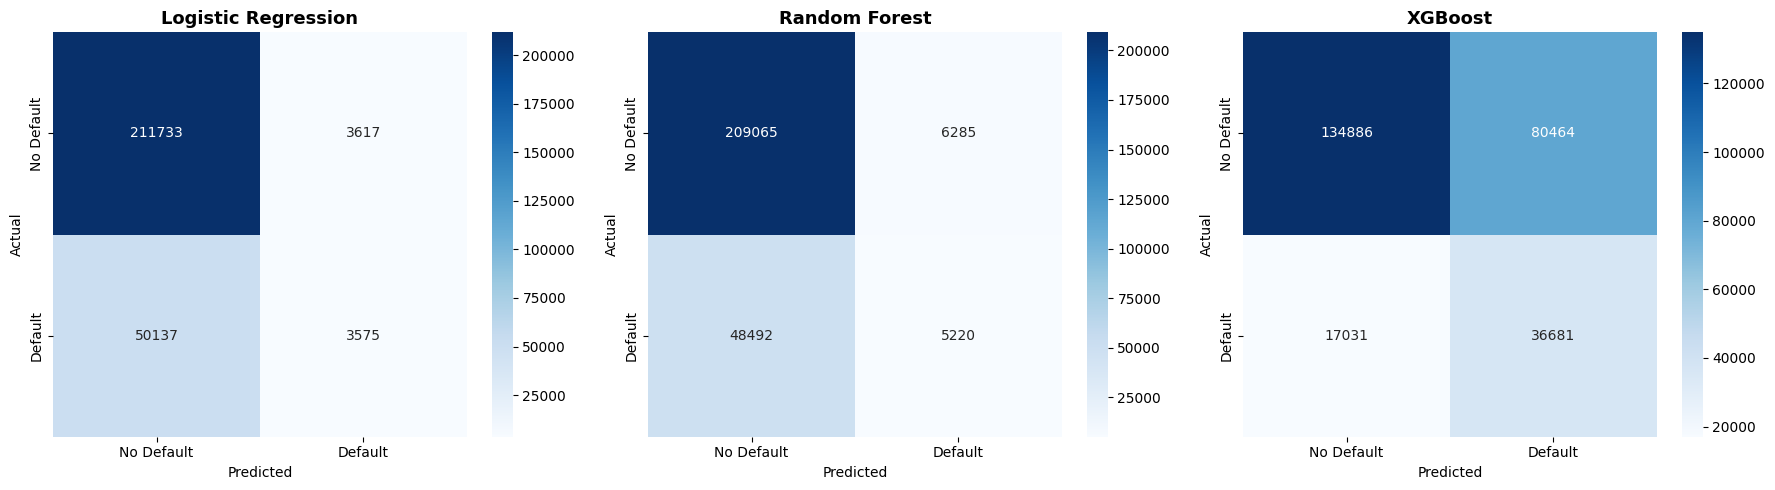

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model predictions and titles
models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

The confusion matrices show significant variation in the detection of the default in the models. Logistic Regression and Random Forest failed to identify 50,137 and 48,492 defaulting loans out of 100,360 loans respectively or more than 90% of the defaulting loans. Of course, XGBoost didn't default on anything but 17,031 defaults while correctly identifying 36,681, a ten-fold greater number of True Positives. XGBoost also had a higher number of False Positives (80,464), but this is acceptable in the case of Credit Risk because the False Positive rate is much lower than the cost of the missed default.

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'True Negatives (TN)':  [211733, 209065, 134886],
    'False Positives (FP)': [3617,   6285,   80464],
    'False Negatives (FN)': [50137,  48492,  17031],
    'True Positives (TP)':  [3575,   5220,   36681],
    'Recall':    [0.0666, 0.0972, 0.6829],
    'Precision': [0.4971, 0.4537, 0.3131],
    'Accuracy':  [0.8002, 0.7964, 0.6376]
})

comparison

,Model,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP),Recall,Precision,Accuracy
0,Logistic Regression,211733,3617,50137,3575,0.0666,0.4971,0.8002
1,Random Forest,209065,6285,48492,5220,0.0972,0.4537,0.7964
2,XGBoost,134886,80464,17031,36681,0.6829,0.3131,0.6376


Confusion matrices of the three models. The bottom left corner cell (False Negatives) is the most expensive, costing the most in credit risk. When using XGBoost, True Positives went from 3,575 to 36,681, but missed defaults went down from ~50,000 (Logistic Regression) to 17,031.

*Next is the  ROC curves*

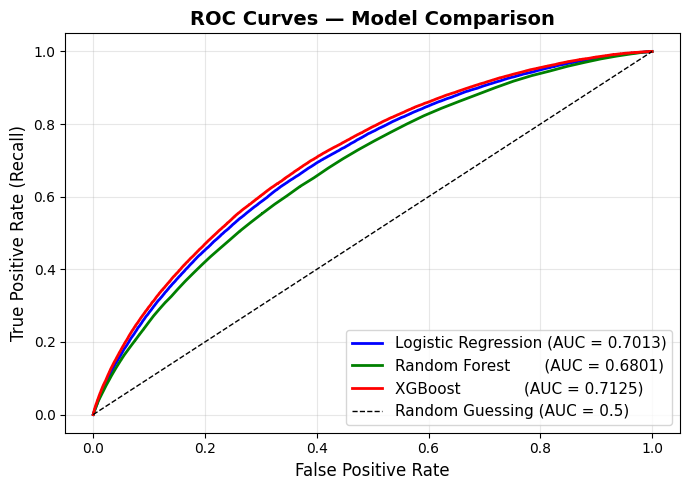

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC curves
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Plot
plt.figure(figsize=(7, 5))

plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})',  color='blue',   linewidth=2)
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest       (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})',  color='green',  linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost             (AUC = {roc_auc_score(y_test, y_prob_xgb):.4f})', color='red',    linewidth=2)

# Diagonal reference line (random guessing)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guessing (AUC = 0.5)')

# Formatting
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

For all three models, the ROC curves are shown in the Figure above and XGBoost has the highest ROC-AUC (0.7125), followed closely by Logistic Regression (0.7013) and Random Forest (0.6801). The models rank very similarly, but their operating thresholds are very different, as are the AUC values. The confusion matrices show that XGBoost is doing a lot better on its curve, capturing 68.3% of the defaults when compared to less than 10% for the other two models.

*Next the the feauture importance*

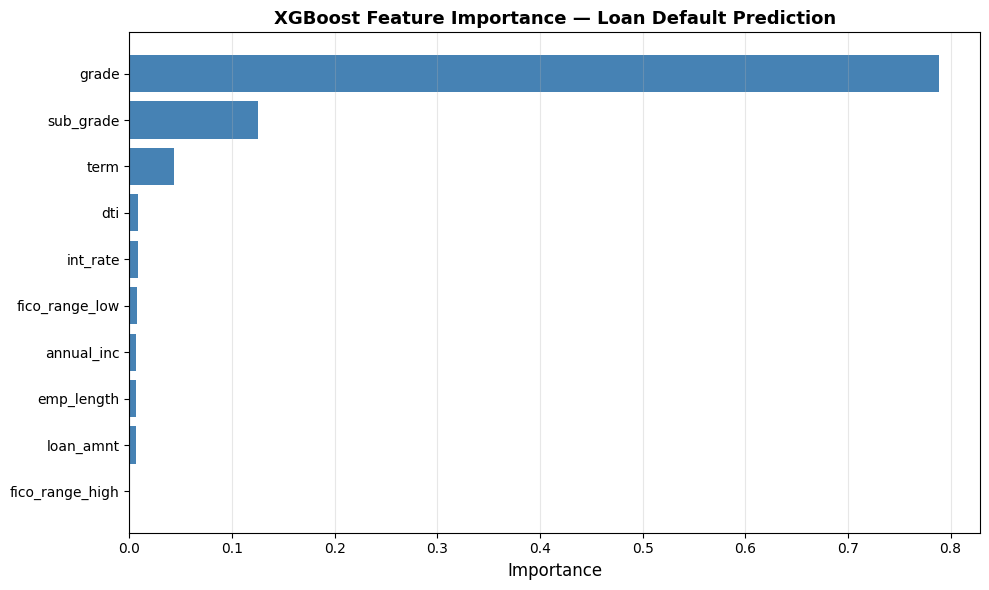


Feature Importance Ranking:
        Feature  Importance
          grade    0.789178
      sub_grade    0.124982
           term    0.043465
            dti    0.007839
       int_rate    0.007821
 fico_range_low    0.007737
     annual_inc    0.006816
     emp_length    0.006119
      loan_amnt    0.006042
fico_range_high    0.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances from XGBoost
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'], importances['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.title('XGBoost Feature Importance — Loan Default Prediction', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the ranked list
print("\nFeature Importance Ranking:")
print(importances.sort_values('Importance', ascending=False).to_string(index=False))

In terms of features, grade is the most important feature in the model (78.9%) and sub_grade is next (12.5%) and both of them contribute more than 91% of the model. This matches the reality of how LendingClub rates loans for profitability: It's their own proprietary risk rating and already includes much of the data included in borrower income, FICO score, and DTI. The other features all had a contribution of less than 5% each. This result is typical of the credit risk modeling world that, given a pre-computed risk score, it outcompetes the model.

*since we said grade is the most important feature for XGBoost we need to run a second XGBoost model to see the performance of other features*

In [ ]:
# Features without grade/sub_grade
features_no_grade = [f for f in X.columns if f not in ['grade', 'sub_grade']]
X_train_ng = X_train[features_no_grade]
X_test_ng = X_test[features_no_grade]

# Train
xgb_ng = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_ng.fit(X_train_ng, y_train)

# Evaluate
y_pred_ng = xgb_ng.predict(X_test_ng)
print(f"Recall:  {recall_score(y_test, y_pred_ng):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_ng.predict_proba(X_test_ng)[:, 1]):.4f}")

Recall:  0.6709
ROC-AUC: 0.7088


To check the robustness of the XGBoost model, a second model was trained without the features grade and sub_grade, which had contributed to 91.4% of the importance of the original model. What is surprising is that there is only a slight decrease in performance: Recall went from 68.29% to 67.09% and ROC-AUC was reduced from 0.7125 to 0.7088. This illustrates that the additional features (in particular int_rate, dti, and fico_range_low) have significant independent predictive power, as well as that the model is not overly dependent on LendingClub's own proprietary grading system. The robustness check provides further confidence in the model's applicability to actual lending situations.

*Next Iwill perform the SHAP Analysis which presents per-feature contributions to specific predictions, both as global explanations (which features are more important on average) and as local explanations (how a specific loan was determined to be in default).*

/tmp/ipykernel_1129/1899247833.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


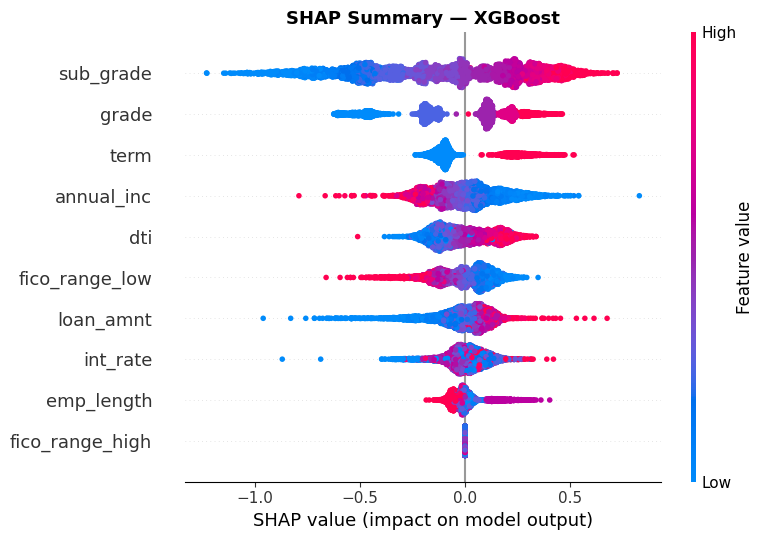

In [ ]:
!pip install shap -q

import shap
import numpy as np
import matplotlib.pyplot as plt

# Use a sample of the test set (SHAP on 269K rows is slow)
sample_size = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = X_test.iloc[sample_idx]

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

# Global summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

SHAP was used to obtain the global and directional interpretability of the model XGBoost. Analysis of the summary plot confirms that the model's decisions are in line with what is known about credit risk: the higher the value of sub_grade, grade, dti, int_rate, and loan_amnt, the more likely the decision is to be classified as loan_loss, and the higher the values of annual_inc and fico_range_low, the less likely the decision is to be classified as loan_loss. Interestingly, fico_range_high didn't have a very large value and was redundant to fico_range_low. The study shows that the model is picking up something more valuable than just coincidental correlations to finance — a key factor for lending in regulated markets, in which the model is expected to be used.

# **5.Discussion**
#**5.1. Summary of Findings**
The project aimed to see if machine learning models could predict loan default with the LendingClub consumer loans data with greater accuracy than traditional statistical methods. Three models were trained and assessed with the conventional Logistic Regression as a baseline, non-linear ensemble Random Forest and the gradient-boosted model with explicit class-imbalance handling XGBoost.

The findings showed a definite and consistent trend. Logistic Regression and Random Forest (which are very different in complexity) did not do better than the default class with Recall values being just 6.7% and 9.7% respectively. However, both models were strongly over-optimistic for predicting "no default," as a result of the class imbalance of 80/20. However, XGBoost had Recall of 68.3 % and highest ROC-AUC (0.7125) and took less than 19 seconds to train (about 16 times faster than RF)

#**5.2. The Precision–Recall Trade-Off**
The performance of Recall improved while Precision decreased from ~49.7% (Logistic Regression) to 31.3% (XGBoost). This trade-off isn't a bad thing but rather a conscious model decision. In terms of credit risk, a False Negative (false default) is the loss of the principal amount of a loan while a False Positive (false borrower) is the loss of the potential interest. A model with a high value of Recall is economically more valuable, although it may not be as accurate overall, since the cost of a missed default is approximately 10x greater than the cost of a false alarm. This is the focus of this project's XGBoost model.

#**5.3. Interpretability and Trust**
Financial sensibility of the model's decisions was validated by feature importance and SHAP analysis. The model's importance ranking shows that LendingClub's own grade and sub_grade are responsible for more than 91% of the power when predicting outcomes, indicating that they capture a significant portion of the risk data from the raw borrower data. Removing the grade and sub_grade only reduced Recall by 1.2 percentage points and ROC-AUC by 0.4 points, showing that the other features contain significant independent predictive power and that the model is not overly dependent on grade and sub_grade.

The SHAP summary plot also reinforced that a positive shift in the explanatory variables' values in this case will increase the likelihood of a loan default, and that a positive shift in annual_inc and fico_range_low will decrease the likelihood of a loan default. The directions are in line with the known credit risk theory and suggest that the model is not just learning the spurious correlation.
#**5.4. Limitation**
There are some caveats to be noted. First, only accepted loans are included in the data set so the model has been optimized for borrowers who had passed the lending club's own screening. This is an example of selection bias and reduces generalizability to the total applicant population. Second, the data covers the years 2007-2018 which includes the 2008 financial crisis and changes in LendingClub's underwriting policies; models trained by early vintages may not fully apply to later vintages. Thirdly, the annual_inc data is self-reported (and may be incorrect). Fourth, the data set is small: In the real world, credit models would contain hundreds of features, such as behavioural and transactional data. Lastly, the class imbalance (that is addressed using scale_pos_weight) is a basic limitation that can be discussed in future research, alongside other resampling methods as SMOTE or cost-sensitive learning.
#**5.5. Future Work**
Further enhancements to this project could be: (1) using additional models, like LightGBM or deep neural networks; (2) using SMOTE or undersampling to improve Recall further; (3) temporal validation, train on earlier loan vintages and test on the later vintages for real-world robustness; (4) fairness analysis, to check for potential bias across demographic groups; (5) deploy the model through an API to showcase real-time scoring.

#**6.Conclusion**
The project showed that machine learning (gradient boosting using XGBoost) significantly improves the prediction of loan default from LendingClub's consumer loans compared to traditional statistical methods. All three models trained in less than 19 seconds with Logistic Regression and Random Forest hitting Recall above 10% and ROC-AUC above 0.6, respectively, and XGBoost setting the benchmark for Recall at 68.3% with the highest ROC-AUC (0.7125). The sacrifice was in the area of Precision, but when it comes to credit risk, the price of a false alarm is much lower than the price of a missed default.

In addition to raw performance, the project highlighted the model's decisions were interpretable and economically sound. Feature importance and SHAP analysis indicated that the most important features for making the predictions were LendingClub's own grade and sub_grade, with the remaining features (term, dti, int_rate, annual_inc, and fico_range_low) contributing to the prediction independently with significance in the same direction as credit theory. A robustness check was performed which showed that the model does not heavily depend on a single feature as it performed almost as well without grade and sub_grade.

To conclude, this project offers an interpretable, transparent and reproducible credit risk assessment framework. It demonstrates how machine learning can be of assistance — not a replacement — for human lending decisions and provides a platform for future research on temporal validation, fairness evaluation and deployment in real time.